# 02 · Reward function & leaderboard submission

**Your task.** Write a function `reward(reactor) -> float` that scores a cultivation run so
that ranking the reactors by that score reproduces the expert's ranking.

The challenge has two stages:

```
TRAINING
--------
6 experiments: 20294, 20293, 17201, 16738, 16748, 16736
Expert ranking is KNOWN (printed below).
Evaluation is performed LOCALLY, here in the notebook.
Metric: Kendall's tau-b.

VALIDATION
----------
5 experiments: 16737, 16742, 17191, 17193, 20285   (numeric order, NOT rank order)
Expert ranking is HIDDEN on the challenge server.
Only the SERVER can calculate your score.
You submit a ranking; the server returns Kendall's tau-b and updates the leaderboard.
```

The training score is only for developing your reward function. The **competition score is
the validation Kendall tau-b**, computed server-side.

This notebook contains no validation answers — they are not in the repository at all.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reward_shaping import (
    load_training, load_validation, build_reactors, growth_rate,
    TRAINING_EXPERT_RANKING, VALIDATION_IDS,
    evaluate_training, ranking_from_scores, plot_ranking_comparison,
    submit_validation_ranking, API_URL,
)

train_reactors = build_reactors(load_training())

print("training expert ranking (best -> worst):")
for rank, i in enumerate(TRAINING_EXPERT_RANKING):
    print("  %d.  %d" % (rank + 1, i))

training expert ranking (best -> worst):
  1.  20294
  2.  20293
  3.  17201
  4.  16738
  5.  16748
  6.  16736


## What's in a `reactor`

`build_reactor(experiment)` returns a dict. The pieces you are most likely to use:

| key | contents |
|---|---|
| `reactor["observations"]["X"]` | `(t, X)` — biomass, g/L, on the reactor clock |
| `reactor["observations"]["S"]` | `(t, S)` — glucose, g/L (at-line) |
| `reactor["observations"]["A"]` | `(t, A)` — acetate, g/L |
| `reactor["observations"]["DOTm"]` | `(t, DOTm)` — dissolved O₂, fraction of air saturation |
| `reactor["pulses"]` | `(t, volume_L, concentration_gL)` — the glucose boluses delivered |
| `reactor["initial"]` | `{"X":..., "S":..., "A":..., "DOTm":..., "V":...}` at `t = 0` |
| `reactor["horizon"]` | duration integrated, h (`end - biomass_start`) |

Handy derived quantities:

```python
t, X   = reactor["observations"]["X"]
X_final = X[-1]                                   # or X.max() for the peak
pt, vol_L, conc_gL = reactor["pulses"]
glucose_fed_g = float((vol_L * conc_gL).sum())    # total glucose fed, grams
t_dense, mu, X_dense, X_at_samples = growth_rate(t, X)   # smoothing-spline growth rate, 1/h
```

In [2]:
def reward(reactor):
    """Baseline: final biomass per gram of glucose fed. (A yield-like quantity.)"""
    t, X = reactor["observations"]["X"]
    _, vol_L, conc_gL = reactor["pulses"]
    glucose_fed_g = float((vol_L * conc_gL).sum())
    return float(X[-1]) / glucose_fed_g

training reactors scored: 6
expert order   : [20294, 20293, 17201, 16738, 16748, 16736]
predicted order: [16738, 20293, 16736, 17201, 20294, 16748]
Training Kendall tau: -0.067


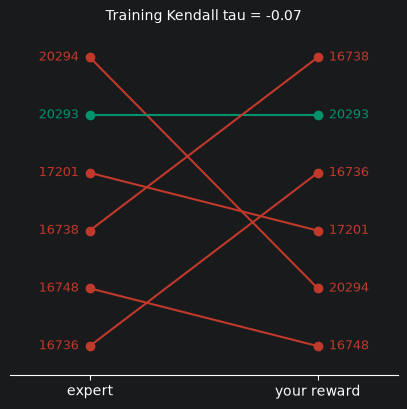

In [3]:
def score_training(reward_fn, higher_is_better=True):
    scores = {i: reward_fn(r) for i, r in train_reactors.items()}
    result = evaluate_training(scores, higher_is_better=higher_is_better)
    print(result["summary"])
    fig, ax = plt.subplots(figsize=(5, 4.5))
    plot_ranking_comparison(scores, higher_is_better=higher_is_better, ax=ax)
    plt.show()
    return scores, result

scores, result = score_training(reward)

## Reading the result

- **Training Kendall tau** — how close your predicted order of the six training reactors is
  to the expert's (`+1` = identical, `0` = unrelated, `-1` = reversed). This is the same
  metric the server uses on the validation set.
- the **slope chart** — a flat green line is a reactor placed exactly right; a red crossing
  is a swap.

The baseline barely correlates with the expert — that is expected. Ideas to build on it:

- **penalise acetate accumulation** — e.g. subtract `max(A)` or the time-integral of `A`.
- **penalise glucose pile-up** — the process is meant to be carbon-limited; `max(S)` or
  `mean(S)` above ~0 is a feeding fault.
- **penalise DOT crashes** — fraction of time `DOTm < 0.1` (oxygen limitation) or `DOTm`
  spiking back up (growth stopped).
- **reward sustained growth** — mean or late-window `µ` from `growth_rate`, or the time
  `µ` stays above some threshold; penalise its variance.
- **biomass** — final vs peak `X` (a drop after the peak means lysis / death), or
  space-time yield `X_final / horizon`.
- combine terms with weights; keep it interpretable so you can explain *why* each reactor
  scored as it did.

In [4]:
# ============================================================================
# YOUR REWARD FUNCTION — edit this, then run the cell below to score it.
# ============================================================================
def my_reward(reactor):
    # A first step past the baseline: reward biomass, penalise acetate and left-over glucose.
    # This lifts the training tau but is far from perfect -- your job is to do better
    # (weights? growth rate? DOT? integrals instead of maxima?).
    t, X = reactor["observations"]["X"]
    _, A = reactor["observations"]["A"]
    _, S = reactor["observations"]["S"]

    biomass_term = float(X[-1])
    acetate_pen  = float(np.max(A))
    glucose_pen  = float(np.max(S))

    return biomass_term - 1.0 * acetate_pen - 0.1 * glucose_pen

training reactors scored: 6
expert order   : [20294, 20293, 17201, 16738, 16748, 16736]
predicted order: [20294, 17201, 16738, 20293, 16748, 16736]
Training Kendall tau: 0.733


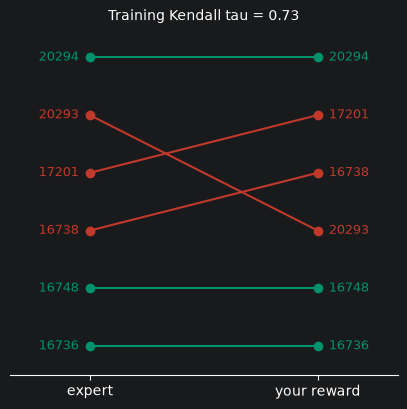

In [5]:
scores, result = score_training(my_reward)

## Submit to the validation leaderboard

The cell below is the **entire** submission step. It

1. builds the five validation reactors,
2. scores them with **your** `my_reward`,
3. turns the scores into a ranking (best → worst), and
4. sends it to the challenge server, which computes Kendall's tau-b against the hidden
   expert ranking and updates the leaderboard.

**Rules enforced by the server:** at most one submission per team every **60 seconds**, at
most **20** submissions per team in total. Set `TEAM_NAME`, then run the cell. Re-run it to
resubmit after improving `my_reward`. Watch the leaderboard at `https://reward-shaping-for-bioprocess-feeding.onrender.com/leaderboard"`.



In [7]:
TEAM_NAME = "Your Team Name"

val_reactors = build_reactors(load_validation())
val_scores = {i: my_reward(r) for i, r in val_reactors.items()}
validation_ranking = [str(i) for i in ranking_from_scores(val_scores)]  # best -> worst

print("team    :", TEAM_NAME)
print("ranking :", validation_ranking)
print("server  :", API_URL, "\n")

response = submit_validation_ranking(team=TEAM_NAME, ranking=validation_ranking)
response

team    : Your Team Name
ranking : ['17191', '17193', '20285', '16737', '16742']
server  : https://reward-shaping-for-bioprocess-feeding.onrender.com 

Submission accepted.

Validation Kendall tau: 0.0
Current leaderboard position: #1
Submissions used: 2 / 20
Next submission available in 60 seconds.


{'accepted': True,
 'team': 'Your Team Name',
 'kendall_tau': 0.0,
 'leaderboard_position': 1,
 'submissions_used': 2,
 'max_submissions': 20,
 'cooldown_seconds': 60}

### What the response means

| field | meaning |
|---|---|
| `kendall_tau` | your validation score for this submission (server-computed) |
| `leaderboard_position` | your team's current rank (by your **best** submission) |
| `submissions_used` / `max_submissions` | how many of your 20 you have spent |
| `error: "rate_limited"` | you submitted within 60 s of your last one — wait and retry |
| `error: "submission_limit_reached"` | you have used all 20 |

The leaderboard shows only each team's **best** tau. Keep iterating on `my_reward` and
resubmit.